# Автоматическое дифференцирование в JAX

**Семинар.** Конечные разности против автограда, оценки градиента нулевого порядка, якобианы (forward vs backward), произведения гессиана на вектор.

Ко всему, что здесь считается, есть один общий вопрос: *сколько стоит производная и насколько ей можно верить?* Ответ на него у трёх подходов принципиально разный.

| Подход | Точность | Стоимость $\nabla f$ для $f\colon \mathbb{R}^n \to \mathbb{R}$ |
|---|---|---|
| Конечные разности | $\sim\sqrt{\varepsilon_{\text{маш}}}$ | $n+1$ вычислений $f$ |
| Нулевой порядок | смещённая оценка + шум | сколько закажете, но точность растёт как $1/\sqrt{N}$ |
| Автодифференцирование | до машинной точности | $\approx 2$–$4$ вычисления $f$, **не зависит от $n$** |

Последняя строка — главная причина, по которой обучение нейросетей вообще возможно.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from timeit import timeit

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, jacfwd, jacrev, jvp, vjp

jax.config.update("jax_enable_x64", True)

def bench(fn, number=20):
    fn()
    return timeit(fn, number=number) / number

print(jax.__version__, jax.devices())

0.11.1 [CpuDevice(id=0)]


---
## 1. Конечные разности против автограда

### 1.1. Откуда берётся ошибка

Разностная аппроксимация производной опирается на формулу Тейлора:

$$
\frac{f(x+h) - f(x)}{h} = f'(x) + \frac{h}{2}f''(\xi) .
$$

Второе слагаемое — **ошибка усечения**, она линейна по $h$. Но $f(x+h)$ и $f(x)$ вычисляются с погрешностью округления порядка $\varepsilon |f(x)|$, где $\varepsilon$ — машинный эпсилон, и при делении на $h$ эта погрешность **растёт**. Итого

$$
\text{ошибка}(h) \;\lesssim\; \underbrace{\tfrac12 |f''| \, h}_{\text{усечение}} \;+\; \underbrace{\frac{2\varepsilon |f|}{h}}_{\text{округление}} .
$$

Минимум по $h$ достигается при $h^* \sim \sqrt{\varepsilon}$, и значение в минимуме тоже порядка $\sqrt{\varepsilon}$. Для `float64` это $\approx 10^{-8}$: **половина значащих цифр теряется всегда**, как бы аккуратно мы ни выбирали шаг.

Для центральной разности $\frac{f(x\ +\ h)\ -\ f(x\ -\ h)}{2h}$ усечение имеет порядок $h^2$, поэтому $h^* \sim \varepsilon^{1/3}$ и ошибка $\sim \varepsilon^{2/3} \approx 10^{-11}$ — лучше, но всё ещё далеко от машинной точности и вдвое дороже.

In [ ]:
def f(x):
    return jnp.sin(x) * jnp.exp(-x**2 / 4)

def df_analytic(x):
    # производная, выписанная руками, — эталон для сравнения
    return (jnp.cos(x) - 0.5 * x * jnp.sin(x)) * jnp.exp(-x**2 / 4)

df_ad = jax.grad(f)             # вот и весь автоград
x0 = 1.3

def fd_forward(f, x, h):
    return (f(x + h) - f(x)) / h

def fd_central(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

print("аналитически   :", df_analytic(x0))
print("автоград       :", df_ad(x0))
print("forward, h=1e-8:", fd_forward(f, x0, 1e-8))
print("central, h=1e-5:", fd_central(f, x0, 1e-5))

аналитически   : -0.23516893442900405
автоград       : -0.23516893442900408
forward, h=1e-8: -0.2351689398771839
central, h=1e-5: -0.23516893439823325


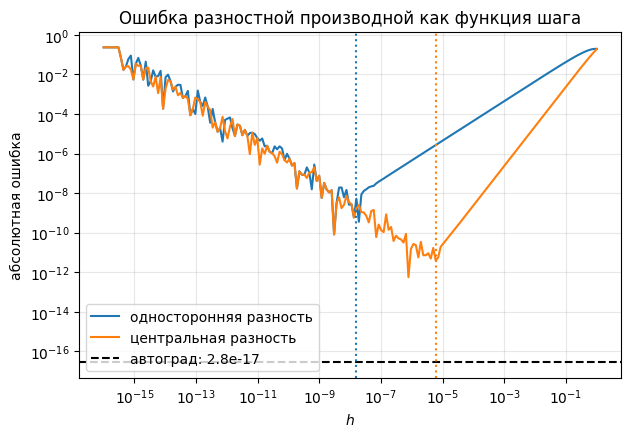

In [ ]:
g_ref = df_analytic(x0)
hs = np.logspace(-16, 0, 200)
err_fwd = np.array([abs(fd_forward(f, x0, h) - g_ref) for h in hs])
err_ctr = np.array([abs(fd_central(f, x0, h) - g_ref) for h in hs])
err_ad  = float(abs(df_ad(x0) - g_ref))

plt.figure(figsize=(7, 4.5))
plt.loglog(hs, err_fwd, label="односторонняя разность")
plt.loglog(hs, err_ctr, label="центральная разность")
plt.axhline(max(err_ad, 1e-17), ls="--", c="k", label=f"автоград: {err_ad:.1e}")
plt.axvline(np.sqrt(np.finfo(np.float64).eps), ls=":", c="C0")
plt.axvline(np.cbrt(np.finfo(np.float64).eps), ls=":", c="C1")
plt.xlabel("$h$"); plt.ylabel("абсолютная ошибка")
plt.title("Ошибка разностной производной как функция шага")
plt.legend(); plt.grid(alpha=.3); plt.show()

Слева от минимума доминирует округление (кривая растёт при уменьшении $h$), справа — усечение. Пунктирные вертикали — теоретические $h^* = \sqrt{\varepsilon}$ и $h^* = \varepsilon^{1/3}$; минимумы кривых ложатся на них. Автоград не имеет параметра, который надо подбирать, и даёт ошибку на уровне машинного эпсилона.

### 1.2. Точность вдоль всей области

Предыдущий график сделан в одной точке. Посмотрим, как ведут себя ошибки на всём отрезке при **фиксированном** (лучшем из возможных) шаге, — так, как их и используют на практике.

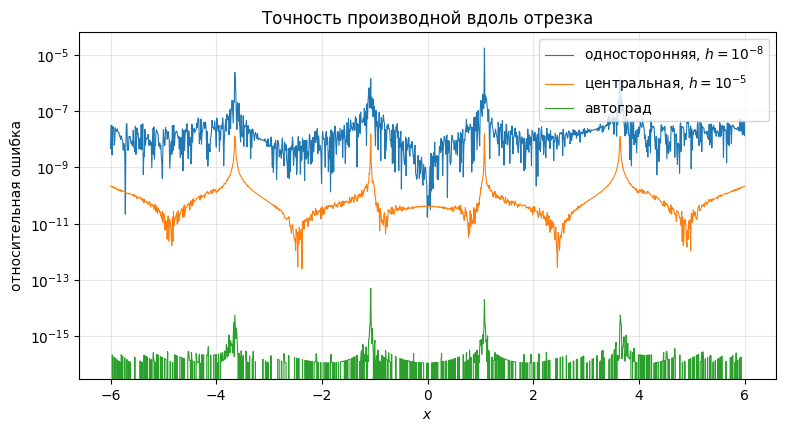

In [ ]:
xs = np.linspace(-6, 6, 1200)
g_exact = np.asarray(df_analytic(xs))

rel = lambda g: np.abs(g - g_exact) / np.maximum(np.abs(g_exact), 1e-300)

err_ad_x  = rel(np.asarray(vmap(df_ad)(xs)))
err_fwd_x = rel(np.asarray(fd_forward(f, xs, 1e-8)))
err_ctr_x = rel(np.asarray(fd_central(f, xs, 1e-5)))

plt.figure(figsize=(9, 4.5))
plt.semilogy(xs, err_fwd_x, lw=.8, label="односторонняя, $h=10^{-8}$")
plt.semilogy(xs, err_ctr_x, lw=.8, label="центральная, $h=10^{-5}$")
plt.semilogy(xs, err_ad_x,  lw=.8, label="автоград")
plt.xlabel("$x$"); plt.ylabel("относительная ошибка")
plt.title("Точность производной вдоль отрезка")
plt.legend(); plt.grid(alpha=.3); plt.show()

Три горизонтальных «полки» — это три уровня точности: $10^{-8}$, $10^{-11}$ и $10^{-16}$. Пики вверх у разностных методов — окрестности нулей производной: абсолютная ошибка там та же, а знаменатель в относительной ошибке стремится к нулю. У автограда пиков нет, потому что он не вычитает близкие числа.

### 1.3. Отказ первый: `float32`

Машинное обучение почти целиком живёт в `float32` (а то и в `bfloat16`), где $\varepsilon \approx 10^{-7}$. Тогда $\sqrt{\varepsilon} \approx 3\cdot 10^{-4}$: **три верные цифры в лучшем случае**.

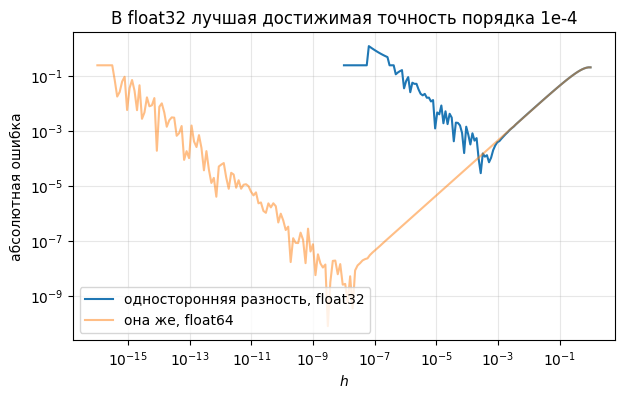

минимальная ошибка float32: 2.8789604022361193e-05


In [ ]:
x32 = np.float32(1.3)
def f32(x):
    x = np.float32(x)
    return np.float32(np.sin(x) * np.exp(-x**2 / 4))

hs32 = np.logspace(-8, 0, 120).astype(np.float32)
err32 = np.array([abs(np.float64((f32(x32 + h) - f32(x32)) / h) - float(g_ref)) for h in hs32])

plt.figure(figsize=(7, 4))
plt.loglog(hs32, err32, label="односторонняя разность, float32")
plt.loglog(hs, err_fwd, alpha=.5, label="она же, float64")
plt.xlabel("$h$"); plt.ylabel("абсолютная ошибка")
plt.title("В float32 лучшая достижимая точность порядка 1e-4")
plt.legend(); plt.grid(alpha=.3); plt.show()

print("минимальная ошибка float32:", err32.min())

### 1.4. Отказ второй: разные масштабы

Ошибка усечения пропорциональна $f''$. Если функция имеет резкий масштаб, например $f(x) = \log(1 + e^{-\beta x})$ с большим $\beta$, то «хорошего» $h$ может не существовать вовсе: шаг, достаточно малый для усечения, уже съеден округлением.

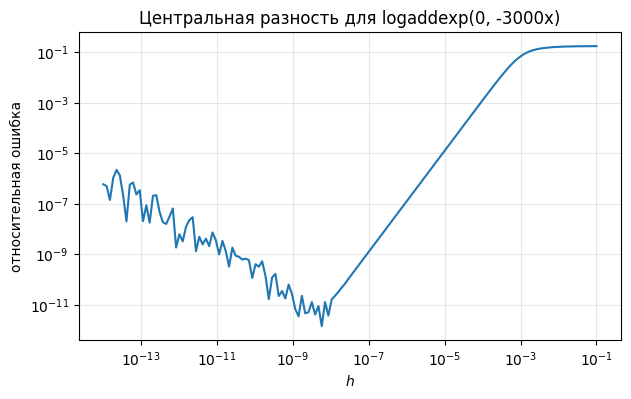

лучшая относительная ошибка разностей: 1.4525728173634796e-12
автоград: -1276.6724495650233


In [ ]:
beta = 3000.0

def sharp(x):
    return jnp.logaddexp(0.0, -beta * x)   # log(1 + exp(-beta x)), численно устойчиво

g_sharp = jax.grad(sharp)
x1 = 1e-4

hs2 = np.logspace(-14, -1, 150)
err_sharp = np.array([abs(fd_central(sharp, x1, h) - g_sharp(x1)) / abs(g_sharp(x1)) for h in hs2])

plt.figure(figsize=(7, 4))
plt.loglog(hs2, err_sharp)
plt.xlabel("$h$"); plt.ylabel("относительная ошибка")
plt.title(f"Центральная разность для logaddexp(0, -{beta:g}x)")
plt.grid(alpha=.3); plt.show()

print("лучшая относительная ошибка разностей:", err_sharp.min())
print("автоград:", g_sharp(x1))

### 1.5. Отказ третий: цена в размерности $n$

Чтобы получить полный градиент конечными разностями, нужно $n+1$ вычисление функции (или $2n$ для центральных разностей). Обратный проход автодифференцирования даёт **весь** градиент за время, сопоставимое с одним-двумя вычислениями $f$, независимо от $n$. Это и есть *cheap gradient principle*.

In [ ]:
def rosenbrock(x):
    return jnp.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1.0 - x[:-1])**2)

grad_rosen = jit(jax.grad(rosenbrock))

def fd_grad(f, x, h=1e-6):
    n = x.shape[0]
    out = np.zeros(n)
    fx = f(x)
    for i in range(n):
        e = np.zeros(n); e[i] = h
        out[i] = (f(x + e) - fx) / h
    return out

for n in [10, 100, 1000]:
    x = jnp.asarray(np.random.default_rng(0).normal(size=n))
    xn_np = np.asarray(x)
    t_ad = bench(lambda: grad_rosen(x).block_until_ready())
    t_fd = bench(lambda: fd_grad(rosenbrock, xn_np), number=1)
    print(f"n = {n:5d}   автоград: {t_ad*1e3:9.3f} мс   "
          f"разности: {t_fd*1e3:10.3f} мс   отношение: {t_fd/t_ad:7.1f}x")

n =    10   автоград:     0.026 мс   разности:      1.361 мс   отношение:    51.6x
n =   100   автоград:     0.028 мс   разности:     17.402 мс   отношение:   620.9x
n =  1000   автоград:     0.029 мс   разности:    309.314 мс   отношение: 10848.3x


### 1.6. Когда ответы просто разные: недифференцируемая точка

До сих пор разности и автоград считали *одно и то же* с разной точностью. Но бывает, что они считают **разные вещи**. Рассмотрим функцию, которая недифференцируема в точке, но имеет производную по любому направлению — например, $f(x) = \max(x, 0)$ в нуле: $f'(0; d) = \max(d, 0)$ существует для всех $d$, но не линейна по $d$, поэтому градиента нет.

Конечная разность в такой точке честно вычисляет **производную по направлению** $+h$ (или $-h$). Автоград вычисляет то, что прописано в правиле дифференцирования примитива, а это некоторый элемент субдифференциала, выбранный разработчиками библиотеки.

In [ ]:
relu_nn  = jax.nn.relu
relu_max = lambda x: jnp.maximum(x, 0.0)
absval   = jnp.abs
h = 1e-6

print("f(x) = max(x, 0) в точке x = 0")
print("  автоград, jax.nn.relu     :", grad(relu_nn)(0.0))
print("  автоград, jnp.maximum     :", grad(relu_max)(0.0))
print("  разность вперёд           :", fd_forward(relu_max, 0.0, h))
print("  разность назад            :", fd_forward(relu_max, 0.0, -h))
print("  центральная разность      :", fd_central(relu_max, 0.0, h))
print()
print("f(x) = |x| в точке x = 0")
print("  автоград                  :", grad(absval)(0.0))
print("  разность вперёд           :", fd_forward(absval, 0.0, h))
print("  разность назад            :", fd_forward(absval, 0.0, -h))

f(x) = max(x, 0) в точке x = 0
  автоград, jax.nn.relu     : 0.0
  автоград, jnp.maximum     : 0.5
  разность вперёд           : 1.0
  разность назад            : -0.0
  центральная разность      : 0.5

f(x) = |x| в точке x = 0
  автоград                  : 1.0
  разность вперёд           : 1.0
  разность назад            : -1.0


Пять разных ответов на вопрос «Чему равна производная?», и все они формально корректны: $0$, $0,5$ и $1$ лежат в субдифференциале $[0, 1]$, а $-1$ и $+1$ для $|x|$ — в $[-1, 1]$. Разница между `jax.nn.relu` и `jnp.maximum` — просто разное соглашение о том, что делать при ничьей.

Посмотрим на это в окрестности нуля: вдали от излома все методы совпадают, а в полосе ширины $h$ разностные производные «размазаны» между ветками.

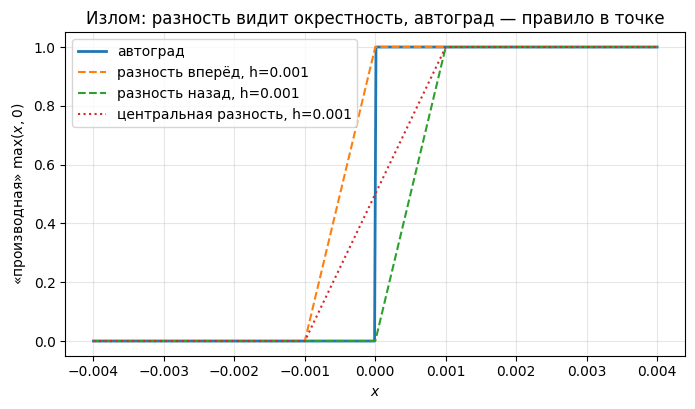

In [ ]:
h = 1e-3
xs = np.linspace(-4e-3, 4e-3, 801)
g_ad  = np.asarray(vmap(grad(relu_max))(jnp.asarray(xs)))
g_fwd = np.asarray(fd_forward(relu_max, xs, h))
g_bwd = np.asarray(fd_forward(relu_max, xs, -h))
g_ctr = np.asarray(fd_central(relu_max, xs, h))

plt.figure(figsize=(8, 4.2))
plt.plot(xs, g_ad,  lw=2, label="автоград")
plt.plot(xs, g_fwd, "--", label=f"разность вперёд, h={h:g}")
plt.plot(xs, g_bwd, "--", label=f"разность назад, h={h:g}")
plt.plot(xs, g_ctr, ":",  label=f"центральная разность, h={h:g}")
plt.xlabel("$x$"); plt.ylabel("«производная» $\\max(x,0)$")
plt.title("Излом: разность видит окрестность, автоград — правило в точке")
plt.legend(); plt.grid(alpha=.3); plt.show()

В многомерном случае расхождение может быть ещё серьёзнее: конечные разности могут выдать вектор, который **вообще не является субградиентом**. Пусть $f(x) = \max(x_1, x_2)$ и $x = (1, 1)$ — точка излома. Субдифференциал здесь отрезок $\{(t, 1-t) : t \in [0,1]\}$, и любая его точка имеет сумму координат $1$. Направленные производные существуют по всем направлениям: $f'(x; d) = \max(d_1, d_2)$.

In [ ]:
fmax = lambda x: jnp.max(x)
xc = jnp.array([1.0, 1.0])
h = 1e-6

def fd_dir(f, x, d, h):
    # разностная производная по направлению d, шаг h — скаляр
    return (f(x + h * d) - f(x)) / h

e1, e2 = jnp.array([1.0, 0.0]), jnp.array([0.0, 1.0])

g_ad = grad(fmax)(xc)
g_fd = jnp.array([fd_dir(fmax, xc, e1, h), fd_dir(fmax, xc, e2, h)])

print("автоград           :", g_ad, "  сумма координат:", float(g_ad.sum()))
print("разности вперёд    :", g_fd, "  сумма координат:", float(g_fd.sum()))
print()
print("направленные производные f'(x; d) для d = e1, e2, (1,1)/√2, (1,-1)/√2:")
for d in [e1, e2, (e1 + e2) / jnp.sqrt(2), (e1 - e2) / jnp.sqrt(2)]:
    dd_ad = float(jvp(fmax, (xc,), (d,))[1])
    dd_fd = float(fd_dir(fmax, xc, d, h))
    print(f"  d = {np.asarray(d).round(3)}:  jvp = {dd_ad: .4f},   разность = {dd_fd: .4f}")

автоград           : [0.5 0.5]   сумма координат: 1.0
разности вперёд    : [1. 1.]   сумма координат: 1.9999999998354667

направленные производные f'(x; d) для d = e1, e2, (1,1)/√2, (1,-1)/√2:
  d = [1. 0.]:  jvp =  0.5000,   разность =  1.0000
  d = [0. 1.]:  jvp =  0.5000,   разность =  1.0000
  d = [0.707 0.707]:  jvp =  0.7071,   разность =  0.7071
  d = [ 0.707 -0.707]:  jvp =  0.0000,   разность =  0.7071


Автоград делит единицу между двумя равными аргументами и возвращает точку субдифференциала. Покоординатные разности дают $(1, 1)$ — вектор с суммой $2$, лежащий *вне* субдифференциала: это не градиент и не субградиент, а просто набор двух направленных производных, склеенных в вектор. При этом направленная производная по любому фиксированному $d$ разностью считается верно, что видно во второй таблице.

Общий вывод: в точках негладкости конечные разности измеряют локальное поведение функции в окрестности радиуса $h$, а автоград исполняет правило, зашитое в примитив. Первое иногда полезнее, второе детерминированно и дёшево, но ни одно не является «истиной», потому что истины в такой точке нет.

---
## 2. Оценки градиента нулевого порядка

### 2.1. Сглаживание по Гауссу

Иногда производных нет вовсе: $f$ — результат симуляции, обращение к внешнему сервису или недифференцируемая метрика. Тогда остаётся **нулевой порядок**: строить оценку градиента только по значениям функции.

Стандартная конструкция — сглаживание по Гауссу. Положим

$$
f_\sigma(x) = \mathbb{E}_{u \sim \mathcal{N}(0,\ I_n)} \, f(x + \sigma u).
$$

Тогда (интегрированием по частям, пользуясь $\nabla_u p(u) = -u\,p(u)$ для гауссовой плотности)

$$
\nabla f_\sigma(x) = \frac{1}{\sigma}\, \mathbb{E}_u \bigl[ f(x + \sigma u)\, u \bigr]
= \frac{1}{\sigma}\, \mathbb{E}_u \bigl[ \bigl(f(x + \sigma u) - f(x)\bigr) u \bigr],
$$

и последнее выражение уже можно оценивать по $N$ выборкам. Двусторонний (антитетический) вариант

$$
\hat g = \frac{1}{N}\sum_{k\ =\ 1}^{N} \frac{f(x + \sigma u_k) - f(x - \sigma u_k)}{2\sigma}\, u_k
$$

имеет меньшую дисперсию при той же цене в вызовах.

In [ ]:
def zo_grad(f, x, key, sigma=1e-3, n_samples=100, antithetic=True):
    n = x.shape[0]
    u = jax.random.normal(key, (n_samples, n))
    if antithetic:
        fp = vmap(lambda ui: f(x + sigma * ui))(u)
        fm = vmap(lambda ui: f(x - sigma * ui))(u)
        coef = (fp - fm) / (2 * sigma)
    else:
        fx = f(x)
        fp = vmap(lambda ui: f(x + sigma * ui))(u)
        coef = (fp - fx) / sigma
    return jnp.mean(coef[:, None] * u, axis=0)

def cos_sim(a, b):
    return float(a @ b / (jnp.linalg.norm(a) * jnp.linalg.norm(b)))

### 2.2. Дисперсия растёт вместе с размерностью

Для одновыборочной оценки

$$
\mathbb{E}\|\hat g\|^2 \;\approx\; n\,\|\nabla f(x)\|^2,
$$

то есть дисперсия линейна по $n$, и оценка из $N$ выборок ведёт себя как градиент, зашумлённый в $\sqrt{n/N}$ раз. Проверим: будем измерять косинус угла между оценкой и истинным градиентом.

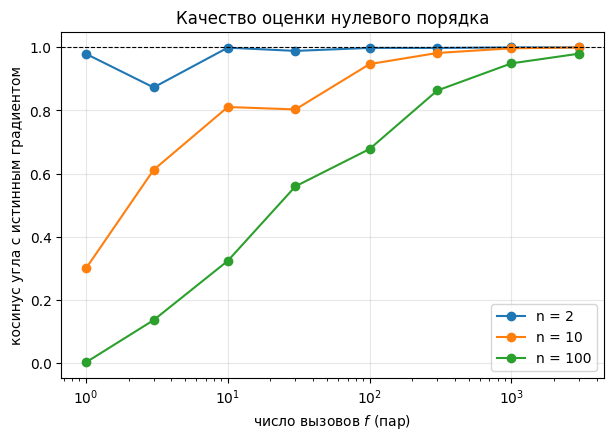

In [ ]:
key = jax.random.PRNGKey(0)
Ns = [1, 3, 10, 30, 100, 300, 1000, 3000]

plt.figure(figsize=(7, 4.5))
for n in [2, 10, 100]:
    xk, k2 = jax.random.split(key)
    x = jax.random.normal(xk, (n,))
    g_true_n = jax.grad(rosenbrock)(x)
    sims = []
    for N in Ns:
        k2, sub = jax.random.split(k2)
        g_hat = zo_grad(rosenbrock, x, sub, sigma=1e-4, n_samples=N)
        sims.append(cos_sim(g_hat, g_true_n))
    plt.semilogx(Ns, sims, "o-", label=f"n = {n}")

plt.axhline(1.0, ls="--", c="k", lw=.8)
plt.xlabel("число вызовов $f$ (пар)"); plt.ylabel("косинус угла с истинным градиентом")
plt.title("Качество оценки нулевого порядка")
plt.legend(); plt.grid(alpha=.3); plt.show()

Чтобы удержать одно и то же качество направления, число вызовов приходится наращивать вместе с размерностью. Отсюда практическое правило: нулевой порядок разумен при $n$ порядка сотен, но не миллионов.


---
## 3. Якобиан: forward или backward?

### 3.1. Два примитива

Пусть $F\colon \mathbb{R}^n \to \mathbb{R}^m$. Автодифференцирование не умеет «просто посчитать якобиан»; оно умеет две вещи:

$$
\underbrace{\texttt{jvp}(F, x, v) = J(x)\,v}_{\text{forward mode, одна колонка направления}},
\qquad
\underbrace{\texttt{vjp}(F, x, u) = u^\top J(x)}_{\text{reverse mode, одна строка направления}} .
$$

Полный якобиан собирается из этих кирпичиков:

* `jacfwd` делает $n$ JVP-вызовов, подавая $v = e_1, \dots, e_n$ — **по столбцу за раз**;
* `jacrev` делает $m$ VJP-вызовов, подавая $u = e_1, \dots, e_m$ — **по строке за раз**.

Отсюда правило:

$$
m \gg n \;\Rightarrow\; \texttt{jacfwd}, \qquad m \ll n \;\Rightarrow\; \texttt{jacrev} .
$$

Градиент — частный случай $m = 1$, поэтому он всегда считается обратным режимом.

In [ ]:
def make_F(n, m, seed=0):
    rng = np.random.default_rng(seed)
    A = jnp.asarray(rng.normal(size=(m, n)) / np.sqrt(n))
    b = jnp.asarray(rng.normal(size=m))
    def F(x):
        return jnp.tanh(A @ x + b) + 0.1 * (A @ x)**2
    return F

# «высокий» якобиан: выходов много, входов мало
F_tall = jit(make_F(n=5, m=2000))
x_tall = jnp.asarray(np.random.default_rng(1).normal(size=5))

J1 = jacfwd(F_tall)(x_tall)
J2 = jacrev(F_tall)(x_tall)
print("совпадают:", jnp.allclose(J1, J2), " форма:", J1.shape)

совпадают: True  форма: (2000, 5)


### 3.2. Высокий против широкого

In [ ]:
jf = jit(jacfwd(F_tall)); jr = jit(jacrev(F_tall))

print("m=2000, n=5   (высокий якобиан)")
print(f"  jacfwd: {bench(lambda: jf(x_tall).block_until_ready())*1e3:8.3f} мс")
print(f"  jacrev: {bench(lambda: jr(x_tall).block_until_ready())*1e3:8.3f} мс")

m=2000, n=5   (высокий якобиан)
  jacfwd:    0.169 мс
  jacrev:   13.629 мс


In [ ]:
# широкий якобиан: входов много, выходов мало
F_wide = jit(make_F(n=2000, m=5))
x_wide = jnp.asarray(np.random.default_rng(2).normal(size=2000))

jf_w = jit(jacfwd(F_wide)); jr_w = jit(jacrev(F_wide))

print("m=5, n=2000   (широкий якобиан)")
print(f"  jacfwd: {bench(lambda: jf_w(x_wide).block_until_ready(), number=5)*1e3:8.3f} мс")
print(f"  jacrev: {bench(lambda: jr_w(x_wide).block_until_ready(), number=5)*1e3:8.3f} мс")

m=5, n=2000   (широкий якобиан)
  jacfwd:   23.256 мс
  jacrev:    0.130 мс


### 3.3. `jvp` и `vjp` по отдельности

`jvp` возвращает пару (значение, производная по направлению), `vjp` — значение и функцию, применяющую $u^\top J$. Ни один из них не строит матрицу $J$ целиком: это оракулы умножения на вектор в том же смысле, что и в линейной алгебре.

In [ ]:
v = jnp.asarray(np.random.default_rng(3).normal(size=2000))
u = jnp.asarray(np.random.default_rng(4).normal(size=5))

val, Jv = jvp(F_wide, (x_wide,), (v,))
val2, vjp_fn = vjp(F_wide, x_wide)
(uJ,) = vjp_fn(u)

J = jacrev(F_wide)(x_wide)
print("JVP верен:", jnp.allclose(Jv, J @ v))
print("VJP верен:", jnp.allclose(uJ, u @ J))

JVP верен: True
VJP верен: True


### 3.4. Гессиан как композиция режимов

Гессиан скалярной функции — это якобиан её градиента. Градиент ($\mathbb{R}^n \to \mathbb{R}$) естественно считать обратным режимом, а якобиан градиента ($\mathbb{R}^n \to \mathbb{R}^n$, квадратный) — любым, но forward дешевле по памяти. Отсюда `jax.hessian = jacfwd(jacrev(f))`.

In [ ]:
hess = jit(jacfwd(jacrev(rosenbrock)))
xs6 = jnp.asarray(np.random.default_rng(5).normal(size=6))
H = hess(xs6)
print(H.shape, "симметричен:", jnp.allclose(H, H.T, atol=1e-8))
print("совпадает с jax.hessian:", jnp.allclose(H, jax.hessian(rosenbrock)(xs6)))

(6, 6) симметричен: True
совпадает с jax.hessian: True


---
## 4. Произведения с гессианом: `hvp` и `vhp`

### 4.1. Гессиан как оракул

Полный гессиан — это $n^2$ чисел. Уже при $n = 10^5$ это $10^{10}$ чисел, то есть 80 ГБ: хранить нельзя. Но чаще всего сам гессиан и не нужен — нужен **оракул** $v \mapsto \nabla^2 f(x)\,v$, ровно в том смысле, в каком итерационным методам линейной алгебры нужен только MatVec.

Ключевое наблюдение:

$$
\nabla^2 f(x)\, v = \left. \frac{d}{dt}\right|_{t\ =\ 0} \nabla f(x + t v),
$$

то есть **производная по направлению от градиента**. Значит, `hvp` — это forward-режим поверх reverse-режима: стоит он как несколько вычислений градиента, а памяти требует $O(n)$.

In [ ]:
def hvp(f, x, v):
    # Hessian-vector product: forward-over-reverse
    return jvp(grad(f), (x,), (v,))[1]

def vhp(f, x, v):
    # vector-Hessian product: reverse-over-reverse
    _, vjp_fn = vjp(grad(f), x)
    return vjp_fn(v)[0]

n = 200
xn = jnp.asarray(np.random.default_rng(7).normal(size=n))
vn = jnp.asarray(np.random.default_rng(8).normal(size=n))

Hv = hvp(rosenbrock, xn, vn)
vH = vhp(rosenbrock, xn, vn)
H_full = jax.hessian(rosenbrock)(xn)

print("hvp верен:", jnp.allclose(Hv, H_full @ vn, atol=1e-8))
print("vhp верен:", jnp.allclose(vH, vn @ H_full, atol=1e-8))
print("hvp == vhp:", jnp.allclose(Hv, vH, atol=1e-8))

hvp верен: True
vhp верен: True
hvp == vhp: True


Последнее равенство не совпадение: по теореме Шварца гессиан симметричен, поэтому $Hv = v^\top H$. Для несимметричного якобиана из раздела 3 `jvp` и `vjp` дают, разумеется, разные вещи.

### 4.2. Стоимость

In [ ]:
hvp_j = jit(lambda x, v: hvp(rosenbrock, x, v))
hess_j = jit(jax.hessian(rosenbrock))
grad_j = jit(jax.grad(rosenbrock))

print(f"n = {n}")
print(f"  один градиент : {bench(lambda: grad_j(xn).block_until_ready())*1e3:8.3f} мс")
print(f"  hvp           : {bench(lambda: hvp_j(xn, vn).block_until_ready())*1e3:8.3f} мс")
print(f"  полный гессиан: {bench(lambda: hess_j(xn).block_until_ready(), number=5)*1e3:8.3f} мс")
print("  памяти под гессиан, МБ:", n * n * 8 / 1e6)

n = 200
  один градиент :    0.036 мс
  hvp           :    0.030 мс
  полный гессиан:    0.316 мс
  памяти под гессиан, МБ: 0.32


### 4.3. Спектр гессиана через оракул

Имея только `hvp`, к гессиану применимы все методы, которым нужен лишь MatVec. Cтепенной метод даёт $\lambda_{\max}(\nabla^2 f)$, который может быть полезен для определения параметров методов оптимизации в будущем.

In [ ]:
def power_method(mv, n, key, n_iter=100):
    # оценка lambda_max через оракул умножения на вектор
    x = jax.random.normal(key, (n,))
    x = x / jnp.linalg.norm(x)
    lam = 0.0
    for _ in range(n_iter):
        y = mv(x)
        lam = jnp.dot(x, y)          # отношение Рэлея
        x = y / jnp.linalg.norm(y)
    return lam, x

mv = lambda v: hvp(rosenbrock, xn, v)
lam_pm, _ = power_method(mv, n, jax.random.PRNGKey(0))
lam_true = jnp.linalg.eigvalsh(H_full)[-1]
print("степенной метод через hvp:", lam_pm)
print("точное lambda_max        :", lam_true)

степенной метод через hvp: 8152.927715965637
точное lambda_max        : 8152.9277159656385


---
## Если кратко

* **Конечные разности** теряют половину значащих цифр всегда ($\sim\sqrt{\varepsilon}$), требуют подбора $h$, деградируют до $10^{-4}$ в `float32` и стоят $n+1$ вычислений функции на один градиент.
* В точках негладкости разности и автоград считают **разные вещи**: первые — направленную производную в окрестности радиуса $h$, второй — зашитый в примитив элемент субдифференциала. Покоординатные разности при этом могут дать вектор, не являющийся субградиентом вовсе.
* **Нулевой порядок** нужен там, где производных нет. Оценка не смещена относительно сглаженной функции $f_\sigma$, но её дисперсия растёт как $n$, а выбор $\sigma$ — тот же компромисс между смещением и шумом.
* **Автодифференцирование** даёт производную с машинной точностью за время, сопоставимое с вычислением самой функции, без параметров, которые нужно настраивать.
* **Forward или reverse** выбирается по форме якобиана: $m \gg n$ — `jacfwd`, $m \ll n$ — `jacrev`. Градиент всегда считается обратным режимом.
* **`hvp`** превращает гессиан в оракул: $O(n)$ памяти вместо $O(n^2)$ и стоимость нескольких градиентов. Этого достаточно для степенного метода, оценки Хатчинсона и любых крыловских методов.